Models loaded: ['MLP', 'LSTM', 'GRU']

===== MODEL COMPARISON =====

  Model  Accuracy  Precision   Recall        F1   ROC-AUC  Training Time (s)
0   MLP   0.77364   0.778474  0.76496  0.771658  0.854041         122.670899
1  LSTM   0.85616   0.862482  0.84744  0.854895  0.928401         455.203655
2   GRU   0.85128   0.893459  0.79768  0.842857  0.931731         722.624639


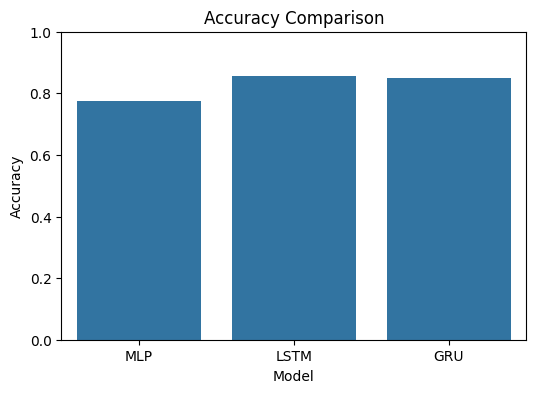

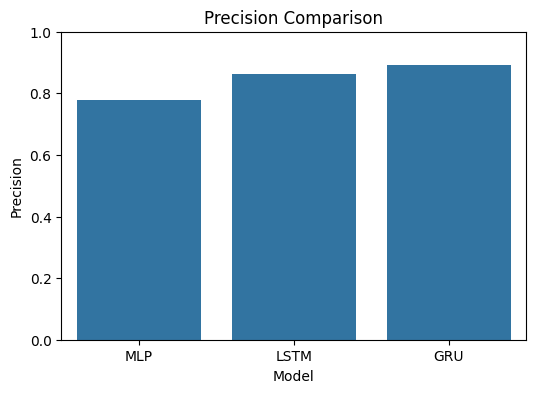

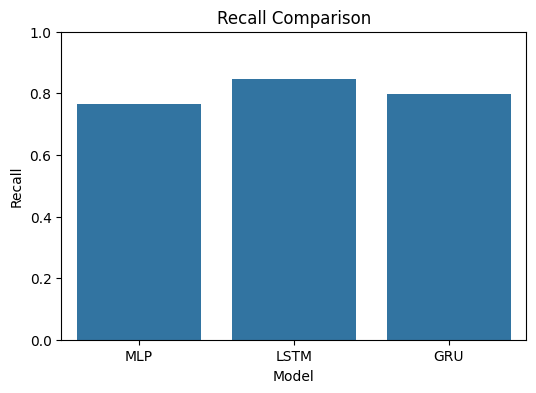

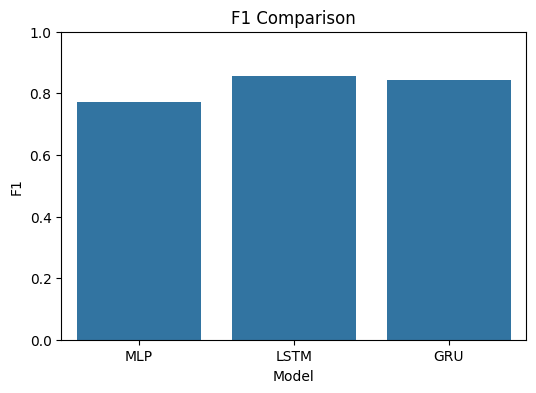

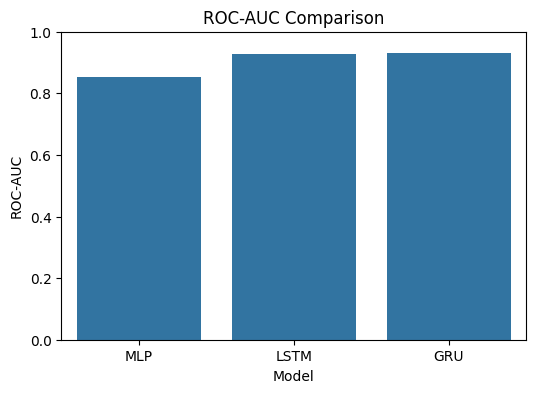

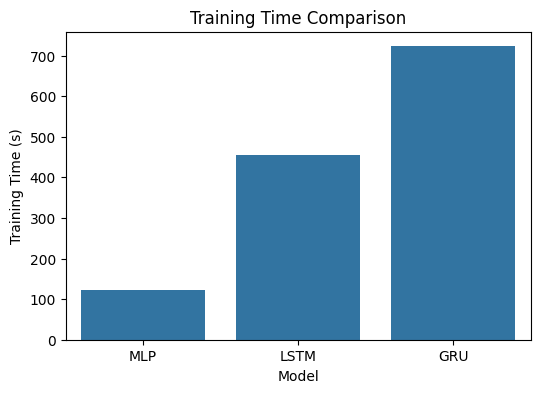

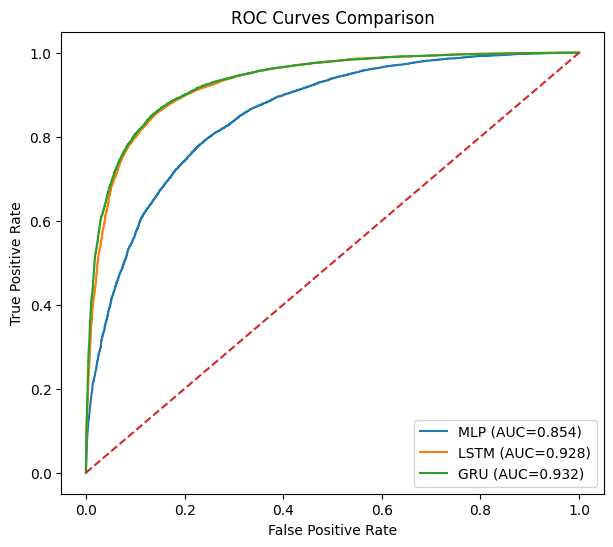

[[9779 2721]
 [2938 9562]]


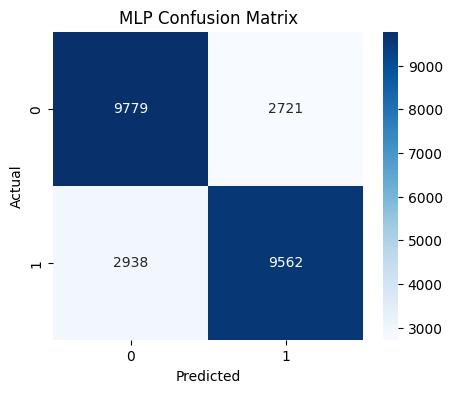

[[10811  1689]
 [ 1907 10593]]


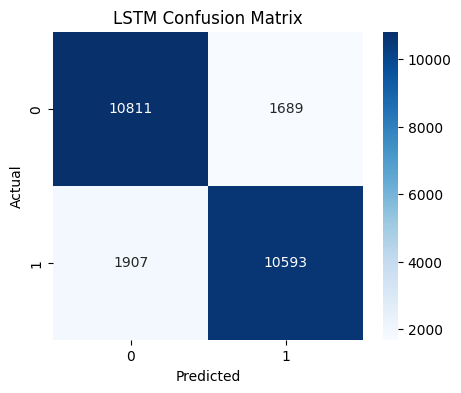

[[11311  1189]
 [ 2529  9971]]


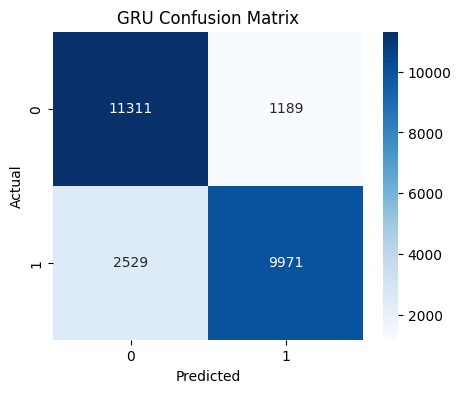

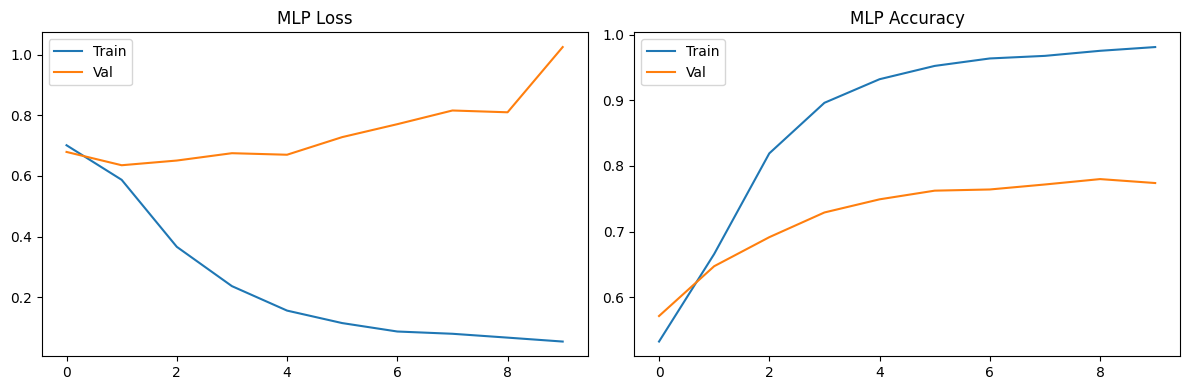

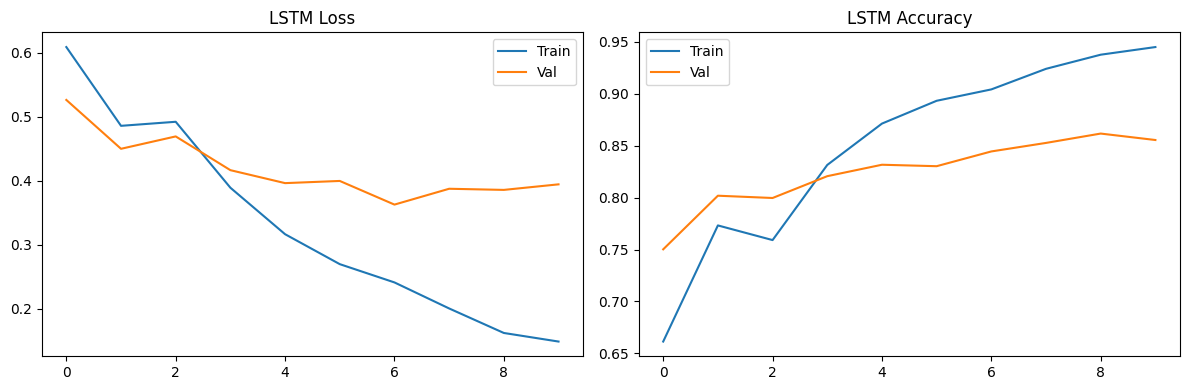

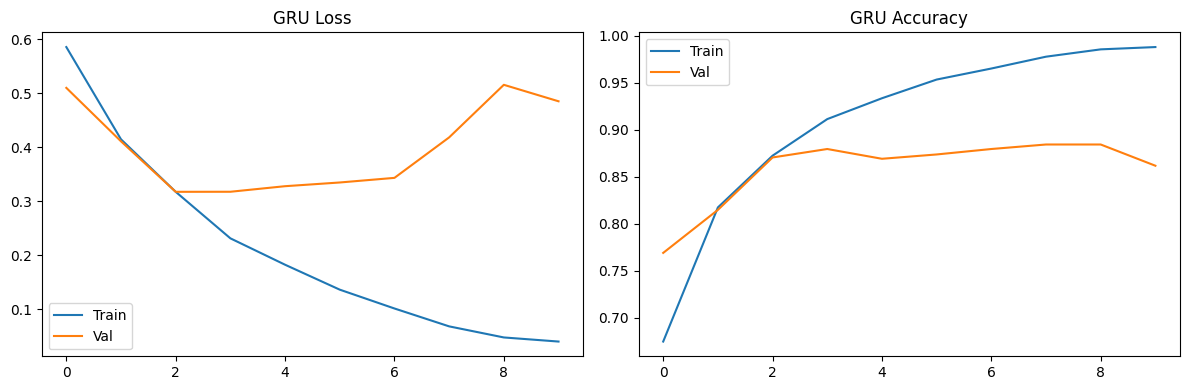


===== BEST MODEL =====

Model                      LSTM
Accuracy                0.85616
Precision              0.862482
Recall                  0.84744
F1                     0.854895
ROC-AUC                0.928401
Training Time (s)    455.203655
Name: 1, dtype: object

===== SUMMARY =====


Best model: LSTM

Key findings:
- Best accuracy: 0.8562
- Best F1-score: 0.8549
- Best ROC-AUC: 0.9317

Observation:
Recurrent models (LSTM/GRU) outperform MLP on sequential text data,
with GRU usually providing best trade-off between quality and speed.


Analysis completed.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,MLP,0.77364,0.778474,0.76496,0.771658,0.854041,122.670899
1,LSTM,0.85616,0.862482,0.84744,0.854895,0.928401,455.203655
2,GRU,0.85128,0.893459,0.79768,0.842857,0.931731,722.624639


In [10]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


os.makedirs("analysis_results", exist_ok=True)

MODEL_FILES = {
    "MLP": "results/mlp_results.pkl",
    "LSTM": "results/lstm_results.pkl",
    "GRU": "results/gru_results.pkl"
}

results = {}


for name, path in MODEL_FILES.items():
    with open(path, "rb") as f:
        results[name] = pickle.load(f)

print("Models loaded:", list(results.keys()))


rows = []

for name, data in results.items():

    y_true = np.array(data["test_labels"])
    y_pred = np.array(data["test_predictions"])
    y_prob = np.array(data["test_probabilities"])

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Training Time (s)": data["training_time"]
    }

    rows.append(row)

df = pd.DataFrame(rows)

print("\n===== MODEL COMPARISON =====\n")
print(df)

df.to_csv("analysis_results/metrics_table.csv", index=False)


metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

for metric in metrics:

    plt.figure(figsize=(6, 4))

    sns.barplot(data=df, x="Model", y=metric)

    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1)

    plt.savefig(f"analysis_results/{metric}.png")
    plt.show()

plt.figure(figsize=(6, 4))

sns.barplot(data=df, x="Model", y="Training Time (s)")

plt.title("Training Time Comparison")

plt.savefig("analysis_results/training_time.png")
plt.show()

plt.figure(figsize=(7, 6))

for name, data in results.items():

    y_true = np.array(data["test_labels"])
    y_prob = np.array(data["test_probabilities"])

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")

plt.legend()

plt.savefig("analysis_results/roc_curves.png")
plt.show()

for name, data in results.items():

    y_true = np.array(data["test_labels"])
    y_pred = np.array(data["test_predictions"])

    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    plt.figure(figsize=(5, 4))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(f"analysis_results/{name}_cm.png")
    plt.show()

for name, data in results.items():

    plt.figure(figsize=(12, 4))

    # LOSS
    plt.subplot(1, 2, 1)
    plt.plot(data["train_losses"], label="Train")
    plt.plot(data["val_losses"], label="Val")
    plt.title(f"{name} Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(data["train_accuracies"], label="Train")
    plt.plot(data["val_accuracies"], label="Val")
    plt.title(f"{name} Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"analysis_results/{name}_learning_curves.png")
    plt.show()


best = df.sort_values("F1", ascending=False).iloc[0]

print("\n===== BEST MODEL =====\n")
print(best)


print("\n===== SUMMARY =====\n")

print(
    f"""
Best model: {best['Model']}

Key findings:
- Best accuracy: {df['Accuracy'].max():.4f}
- Best F1-score: {df['F1'].max():.4f}
- Best ROC-AUC: {df['ROC-AUC'].max():.4f}

Observation:
Recurrent models (LSTM/GRU) outperform MLP on sequential text data,
with GRU usually providing best trade-off between quality and speed.
"""
)

print("\nAnalysis completed.")
df


===== THRESHOLD OPTIMIZATION =====

MLP: best threshold = 0.050
LSTM: best threshold = 0.068
GRU: best threshold = 0.050

===== BUSINESS OPTIMIZED COMPARISON =====

  Model  Best Threshold  Accuracy  Precision   Recall        F1   ROC-AUC  \
0   MLP        0.050000   0.75516   0.700989  0.88992  0.784236  0.854041   
1  LSTM        0.068182   0.80652   0.736790  0.95376  0.831352  0.928401   
2   GRU        0.050000   0.84836   0.813612  0.90376  0.856320  0.931731   

   Training Time (s)  
0         122.670899  
1         455.203655  
2         722.624639  


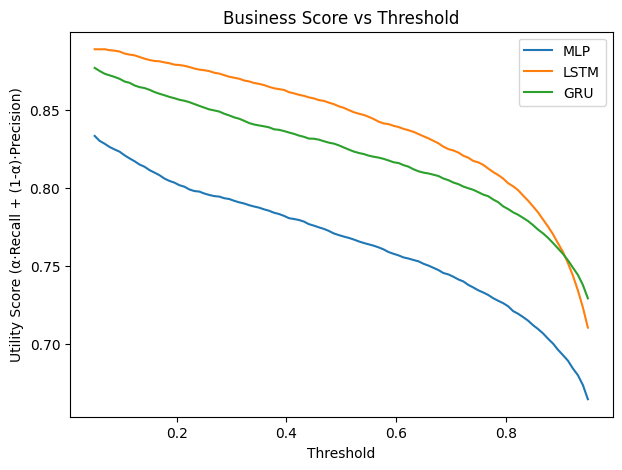

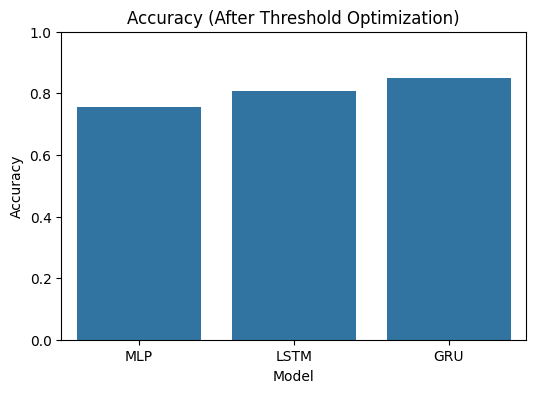

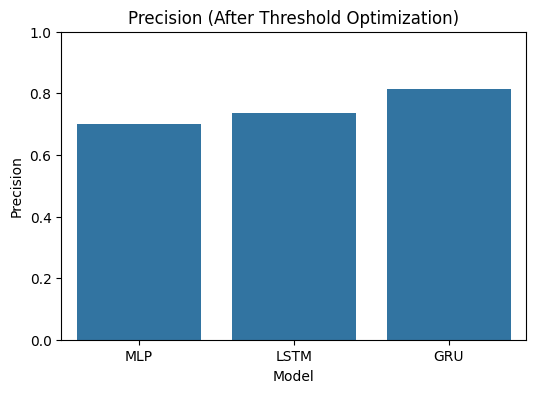

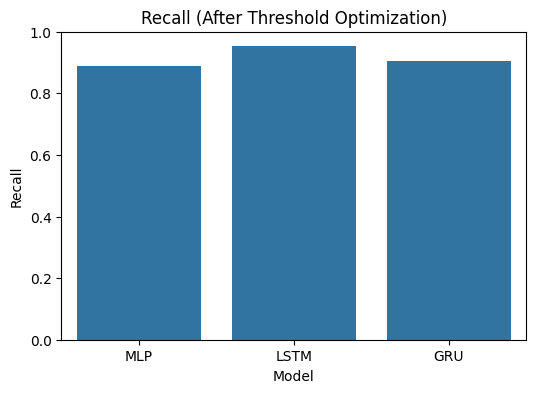

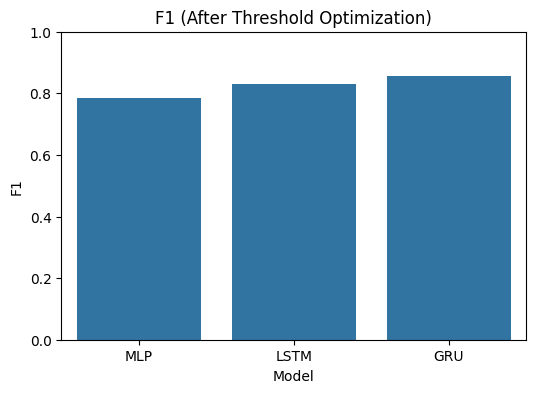

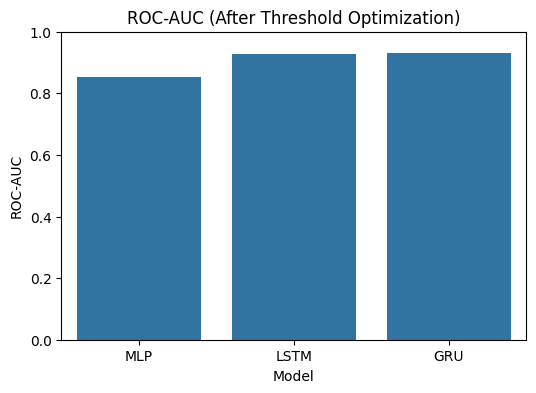

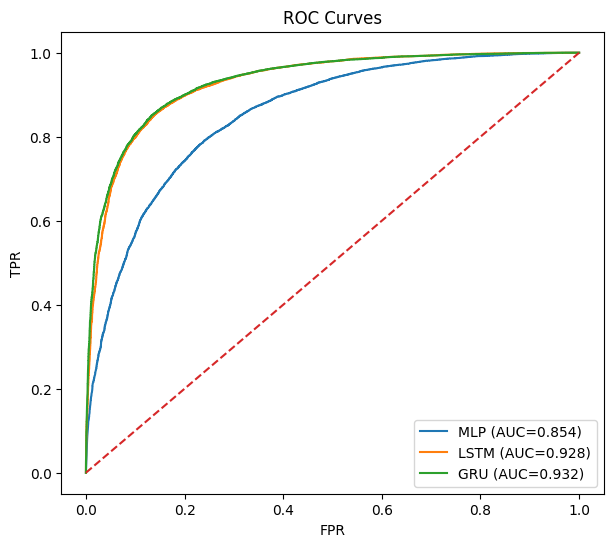

[[ 7755  4745]
 [ 1376 11124]]


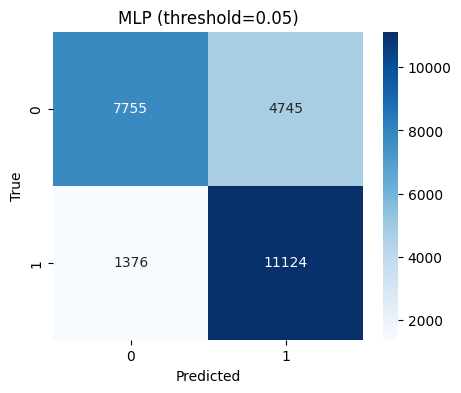

[[ 8241  4259]
 [  578 11922]]


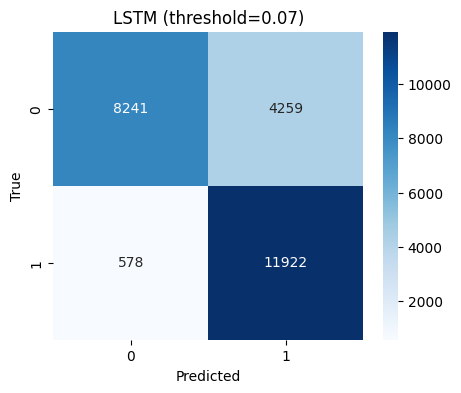

[[ 9912  2588]
 [ 1203 11297]]


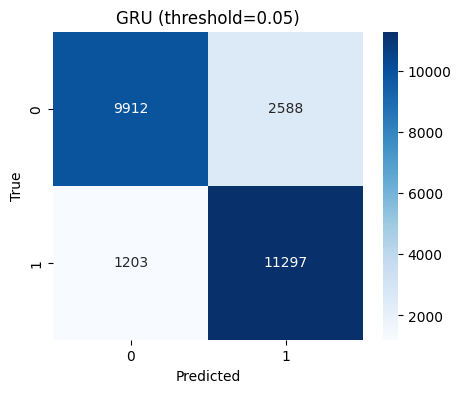


===== BEST BUSINESS MODEL =====

Model                      LSTM
Best Threshold         0.068182
Accuracy                0.80652
Precision               0.73679
Recall                  0.95376
F1                     0.831352
ROC-AUC                0.928401
Training Time (s)    455.203655
Business Score         0.888669
Name: 1, dtype: object


In [9]:
BUSINESS_ALPHA = 0.7

def find_best_threshold(y_true, y_prob, alpha=0.1):

    thresholds = np.linspace(0.05, 0.95, 100)

    best_t = 0.5
    best_score = -1

    scores = []

    for t in thresholds:

        y_pred = (y_prob >= t).astype(int)

        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)

        score = alpha * recall + (1 - alpha) * precision

        scores.append(score)

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, thresholds, scores


results = {}

for name, path in MODEL_FILES.items():
    with open(path, "rb") as f:
        results[name] = pickle.load(f)

best_thresholds = {}

threshold_curves = {}

print("\n===== THRESHOLD OPTIMIZATION =====\n")

for name, data in results.items():

    y_true = np.array(data["test_labels"])
    y_prob = np.array(data["test_probabilities"])

    best_t, thresholds, scores = find_best_threshold(
        y_true, y_prob, BUSINESS_ALPHA
    )

    best_thresholds[name] = best_t
    threshold_curves[name] = (thresholds, scores)

    print(f"{name}: best threshold = {best_t:.3f}")


rows = []

for name, data in results.items():

    y_true = np.array(data["test_labels"])
    y_prob = np.array(data["test_probabilities"])

    t = best_thresholds[name]

    y_pred = (y_prob >= t).astype(int)

    rows.append({
        "Model": name,
        "Best Threshold": t,

        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),

        "Training Time (s)": data["training_time"]
    })

df = pd.DataFrame(rows)

print("\n===== BUSINESS OPTIMIZED COMPARISON =====\n")
print(df)

df.to_csv("analysis_results/business_metrics.csv", index=False)

plt.figure(figsize=(7,5))

for name, (thresholds, scores) in threshold_curves.items():
    plt.plot(thresholds, scores, label=name)

plt.title("Business Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Utility Score (α·Recall + (1-α)·Precision)")
plt.legend()

plt.savefig("analysis_results/threshold_optimization.png")
plt.show()


metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

for metric in metrics:

    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x="Model", y=metric)

    plt.title(f"{metric} (After Threshold Optimization)")
    plt.ylim(0, 1)

    plt.savefig(f"analysis_results/opt_{metric}.png")
    plt.show()


plt.figure(figsize=(7,6))

for name, data in results.items():

    y_true = np.array(data["test_labels"])
    y_prob = np.array(data["test_probabilities"])

    fpr, tpr, _ = roc_curve(y_true, y_prob)

    auc = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"--")

plt.title("ROC Curves")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.savefig("analysis_results/roc_curves.png")
plt.show()


for name, data in results.items():

    y_true = np.array(data["test_labels"])
    y_prob = np.array(data["test_probabilities"])

    t = best_thresholds[name]
    y_pred = (y_prob >= t).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    plt.figure(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"{name} (threshold={t:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.savefig(f"analysis_results/{name}_cm_business.png")
    plt.show()


df["Business Score"] = (
    BUSINESS_ALPHA * df["Recall"] +
    (1 - BUSINESS_ALPHA) * df["Precision"]
)

best = df.sort_values("Business Score", ascending=False).iloc[0]

print("\n===== BEST BUSINESS MODEL =====\n")
print(best)